# General survey analysis
- Loading of data in a consistent manner
    - Exclude withdrawn questions
    - Exclude deep-seek on ollama (model run twice)
- Count and plot responses over time
- Analyse the number of responses per reviewer
- Analyse trends in review behaviour - are there statistically significant behavioural differences?


This table contains the list of questions, and the task numbers, which are used throughout the analysis
![list_tasks.png](list_tasks.png)

# Load data

In [38]:
from analysis_helpers import load_raw

"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import logging
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# PARAMETERS
classifications_csv_path = 'survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = 'survey_responses/analysis/may'
prompts_database_path = 'records_cajetan.db'
ml_responses_database_path = 'records_may_all.db'
subjects_path = 'survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845
exclude_prompts = [17]
exclude_models=['ollama_chat/deepseek-r1:8b']

In [39]:
from pathlib import Path

current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

output_dir = Path(output_dir)

In [42]:
combined_final = load_raw(classifications_csv_path, subjects_path, prompts_database_path, exclude_models=exclude_models, exclude_prompt_ids=exclude_prompts, workflow_id=workflow_id)

In [61]:
classification_lines = pd.read_csv(classifications_csv_path)
total_classifications = classification_lines.shape[0]
total_classifications

221

In [58]:
count_not_logged_in_classifications = classification_lines.user_name.str.match('not-logged-in').sum()
count_not_logged_in_classifications

np.int64(30)

In [63]:
from analysis_helpers import get_count_completed_tasks

classifications_df[['count_completed_tasks', 'final_completed_task_no']] = classifications_df.annotations.apply(
        get_count_completed_tasks)

In [65]:
classifications_df['final_completed_task_no'].value_counts()

final_completed_task_no
8     205
9      10
10      6
Name: count, dtype: int64

In [ ]:
count_classifications_of_withdrawn_prompts = classification_lines.prompt_id

In [59]:
count_classifications_per_user = classification_lines.user_name.value_counts()
count_classifications_per_user

user_name
zzh0505                               52
NicolasH.                             24
hanhuizhen                            16
Manish11                              15
pietro78b                             13
DasAlany                              11
eliasiq2008                           10
ZXPhuang                              10
qtu-ubc                                8
lapatou                                8
artur-lca                              7
laicai98                               6
qqq529                                 5
not-logged-in-059cfadc76ebcbc9cdc7     5
not-logged-in-e364ec368e9150068bf2     4
not-logged-in-74ea738bf155de78a1a7     3
not-logged-in-7dba5f2fb29fe280c027     3
not-logged-in-8988394d059fbae74d02     2
not-logged-in-4a33888898b2bb62d64b     2
qingyang                               2
kirksmim                               2
not-logged-in-3f5de1f98a60f4af4734     1
not-logged-in-bd0c33661e3a5ad6a765     1
not-logged-in-f2a653c3608b69ad462e     1
not-lo

# Plot responses over time

In [13]:
sns.set_theme(style="darkgrid")
# Wrap x-tick labels and rotate
def wrap_labels(ax, width, break_long_words=True):
    xlabels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        parts = text.split('-')
        wrapped_parts = [textwrap.fill(part, width=width, break_long_words=break_long_words) for part in parts]
        wrapped_text = ' '.join(wrapped_parts)
        xlabels.append(wrapped_text)
    ax.set_xticks(ax.get_xticks())  # Set ticks explicitly
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ylabels=[]
    for label in ax.get_yticklabels():
        text = label.get_text()
        ylabels.append(textwrap.fill(text, width=width, break_long_words=break_long_words))
    ax.set_yticks(ax.get_yticks())  # Set ticks explicitly
    ax.set_yticklabels(ylabels, rotation=45, ha='right')

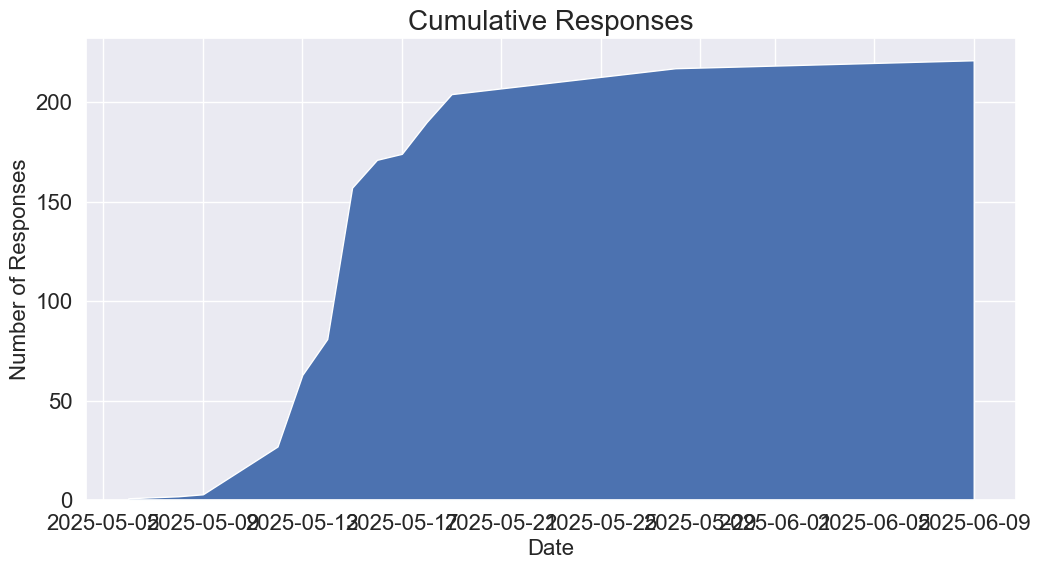

In [14]:
classifications_df = pd.read_csv(classifications_csv_path)

classification_id = classifications_df.classification_id

# Group the data by date and count the number of responses
classifications_df['created_at'] = pd.to_datetime(classifications_df['created_at'])
classifications_df['date'] = classifications_df['created_at'].dt.date
responses_per_day = classifications_df.groupby('date').size()

# Calculate the cumulative sum of responses
cumulative_responses = responses_per_day.cumsum()
plt.figure(figsize=(12, 6))
plt.stackplot(cumulative_responses.index,cumulative_responses.values)
plt.title('Cumulative Responses',fontsize=20)
plt.xlabel('Date',fontsize=16)
plt.ylabel('Number of Responses',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.savefig(output_dir/'responses_timeline_cum.png')


# Plot the number of response per prompt

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


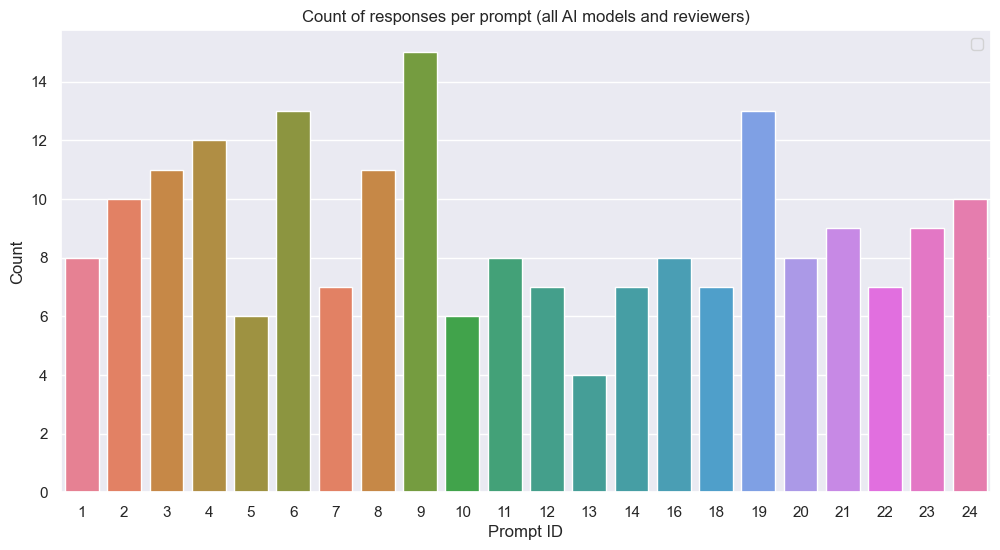

In [43]:
# Calculate value counts for the specified columns
value_counts = combined_final.value_counts(subset=['prompt_id', 'prompt_text'])

# Reset the index to turn the Series into a DataFrame
value_counts_df = value_counts.reset_index(name='count')

# Plot the bar chart using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='prompt_id', y='count', hue='prompt_text', data=value_counts_df)
plt.title('Count of responses per prompt (all AI models and reviewers)')
plt.xlabel('Prompt ID')
plt.ylabel('Count')
# plt.legend(title='Prompt Text', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().legend(labels=[])
plt.show()

C:\Users\Artur\AppData\Local\Temp\ipykernel_26196\953209974.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='#llm_model', y='count', data=grouped_counts, palette='viridis')


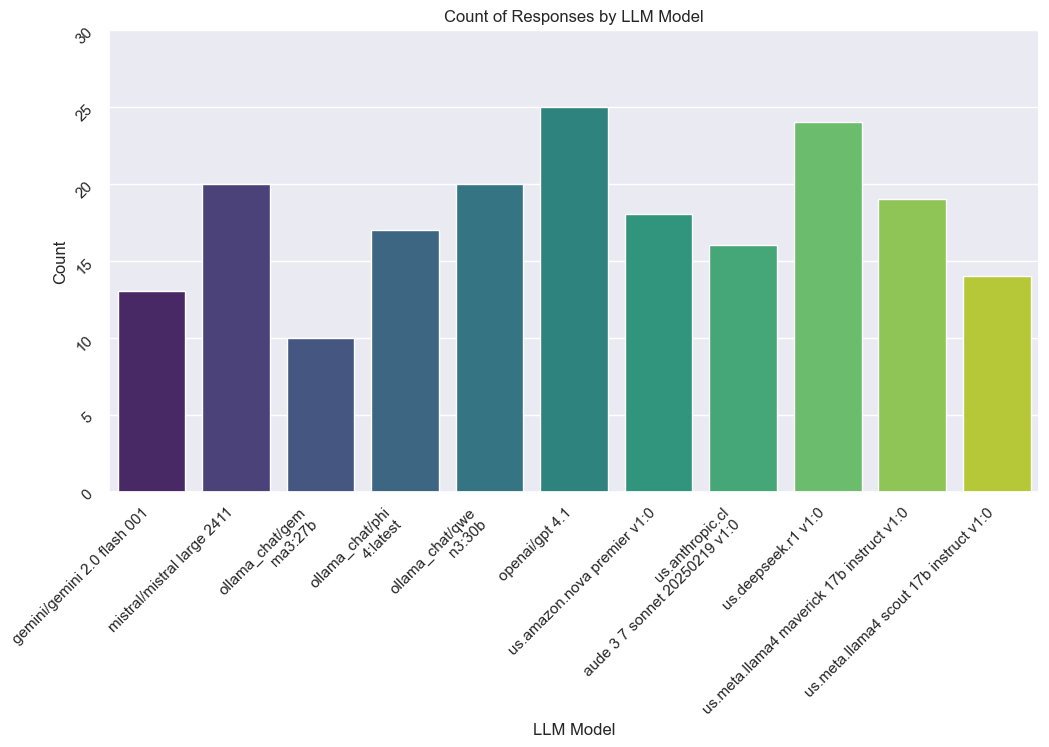

In [44]:
# Group by the 'llm_model' column and calculate the count of each group
grouped_counts = combined_final.groupby('#llm_model').size().reset_index(name='count')

# Plot the bar chart using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='#llm_model', y='count', data=grouped_counts, palette='viridis')
plt.title('Count of Responses by LLM Model')
plt.xlabel('LLM Model')
plt.ylabel('Count')
plt.xticks(rotation=45)
import textwrap

wrap_labels(plt.gca(), width=15)

plt.show()

In [45]:
print(f'There were {classifications_df.shape[0]} responses to the survey, of which {combined_final.shape[0]} were suitable for analysis')

There are 221 responses to the survey, of which 196 were suitable for analysis


# Dump data

In [46]:
combined_final.to_excel(output_dir / f'{Path(classifications_csv_path).name}_analysis_{current_date}.xlsx')